# 01 資料與投資範圍（Universe）

本研究以**元大台灣 50（0050）成分股**作為投資範圍，模擬一位在每季成分股公告日決定投資組合、持有一季後再平衡的投資人。

* **決策點**：0050 於每年 3、6、9、12 月的第一個星期五公告成分股調整。新名單在公告日即為公開資訊，因此以公告日收盤作為決策時點不會用到未來資訊。
* **持有期**：公告日收盤 → 下一季公告日收盤。
* **研究期間**：2025/03 ～ 2026/03 共 5 季（walk-forward）。

資料來源見 [`data/README.md`](../data/README.md)：個股還原股價來自 FinMind，成分股持股明細來自 TEJ，0050 ETF 基準來自 Yahoo Finance。

In [1]:
import sys, json
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
from qaportfolio.config import load_config
from qaportfolio.pipeline import schedule_from_cfg, load_prices
from qaportfolio import analysis, plotting
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
pd.set_option("display.max_columns", 30)
cfg = load_config()
schedule = schedule_from_cfg(cfg)
SUMMARY = cfg["paths"]["results"] / "summary"

## 1. 時間表：公告日（決策日）與持有期

In [2]:
pd.DataFrame([w.as_dict() for w in schedule])

,quarter,announcement,hold_end
0,2025_03,2025-03-07,2025-06-06
1,2025_06,2025-06-06,2025-09-05
2,2025_09,2025-09-05,2025-12-05
3,2025_12,2025-12-05,2026-03-06
4,2026_03,2026-03-06,2026-06-05


## 2. 各季成分股（universe）

In [3]:
from qaportfolio.data import load_holdings, constituents
holdings = load_holdings(cfg["paths"]["holdings"])
uni = {w.quarter: constituents(holdings, w.quarter) for w in schedule}
print({q: len(v) for q, v in uni.items()})
changes = []
qs = list(uni)
for a, b in zip(qs, qs[1:]):
    changes.append({"from": a, "to": b, "added": sorted(set(uni[b]) - set(uni[a])), "removed": sorted(set(uni[a]) - set(uni[b]))})
pd.DataFrame(changes)

{'2025_03': 50, '2025_06': 50, '2025_09': 51, '2025_12': 50, '2026_03': 49}


,from,to,added,removed
0,2025_03,2025_06,[2383],[3037]
1,2025_06,2025_09,"[2059, 6919]",[1101]
2,2025_09,2025_12,"[2360, 2408, 3653, 3665]","[2609, 4938, 5871, 5876, 6446]"
3,2025_12,2026_03,"[2344, 2368, 2449, 7769]","[2379, 2615, 2912, 3034, 3665]"


## 3. 2025/03 成分股權重（前 15 大）

In [4]:
h = holdings[holdings["年月"] == "2025/03"]
h = h[h["標的碼"].str.isdigit()].sort_values("投資比率％", ascending=False)
h[["標的碼", "標的名稱", "投資比率％"]].head(15).reset_index(drop=True)

,標的碼,標的名稱,投資比率％
0,2330,台積電,55.5000
1,2454,聯發科,5.2400
2,2317,鴻海,4.4000
3,2308,台達電,1.9700
4,2881,富邦金,1.7500
5,2891,中信金,1.6300
6,2382,廣達,1.5200
7,2882,國泰金,1.4200
8,2303,聯電,1.3300
9,2412,中華電,1.2400


## 4. 價格資料與基準

各股票的交易日數： {'count': 61.0, 'mean': 6021.0, 'std': 1868.0, 'min': 412.0, '25%': 5636.0, '50%': 6048.0, '75%': 7562.0, 'max': 8025.0}


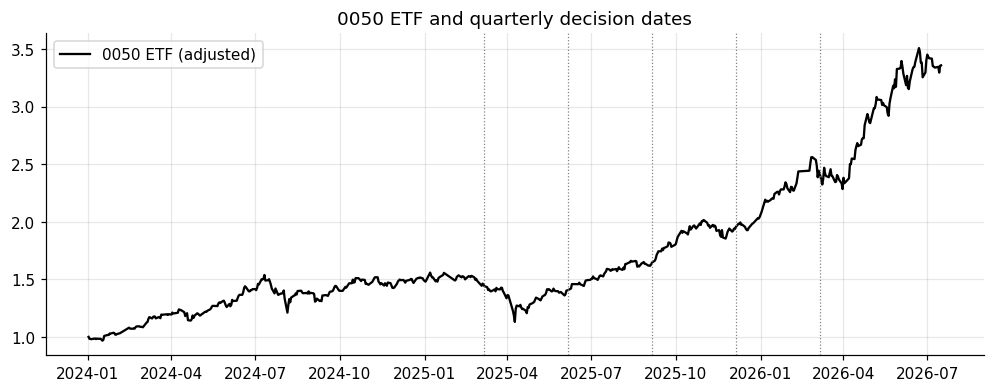

In [5]:
prices = load_prices(cfg)
from qaportfolio.data import load_benchmark
bench = load_benchmark(cfg["paths"]["benchmark"])
fig, ax = plt.subplots(figsize=(11, 3.8))
b = bench.loc["2024-01-01":]
ax.plot(b / b.iloc[0], color="black", label="0050 ETF (adjusted)")
for w in schedule:
    ax.axvline(w.announcement, color="grey", ls=":", lw=0.8)
ax.set_title("0050 ETF and quarterly decision dates"); ax.legend()
coverage = prices.notna().sum().describe()
print("各股票的交易日數：", coverage.round(0).to_dict())